# Online Shoppers Purchasing Intention
## Exploratory analysis and prediction model

This notebook analyzes online shopping sessions from the UCI dataset. The goal is to predict whether a session will end with a purchase (`Revenue`). The classes are unbalanced, so we use more than accuracy: ROC-AUC, PR-AUC, F1 score, and balanced accuracy.

## 1. Import libraries and set up the analysis

We use `random_state=42`, so the experiment can be repeated. The data is downloaded directly from UCI.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_recall_curve, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
CV_SPLITS = 5
sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_columns', 30)

## 2. Download and inspect the data

In [2]:
dataset = fetch_ucirepo(id=468)
X = dataset.data.features.copy()
y_raw = dataset.data.targets.squeeze().copy()
y = y_raw.astype(str).str.lower().map({'true': 1, 'false': 0}).rename('Revenue')

print(f'Number of sessions: {X.shape[0]:,}')
print(f'Number of features: {X.shape[1]}')
print(f'Missing values: {int(X.isna().sum().sum())}')
display(pd.DataFrame({'type': X.dtypes.astype(str), 'missing': X.isna().sum(), 'unique values': X.nunique()}))
display(X.head())

Number of sessions: 12,330
Number of features: 17
Missing values: 0


,type,missing,unique values
Administrative,int64,0,27
Administrative_Duration,float64,0,3335
Informational,int64,0,17
Informational_Duration,float64,0,1258
ProductRelated,int64,0,311
ProductRelated_Duration,float64,0,9551
BounceRates,float64,0,1872
ExitRates,float64,0,4777
PageValues,float64,0,2704
SpecialDay,float64,0,6


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True


## 3. Analyze the target variable

A purchase is the minority class. This affects the metrics we use and supports the use of `class_weight='balanced'`.

,count,share
class,,
No purchase,10422,84.5%
Purchase,1908,15.5%


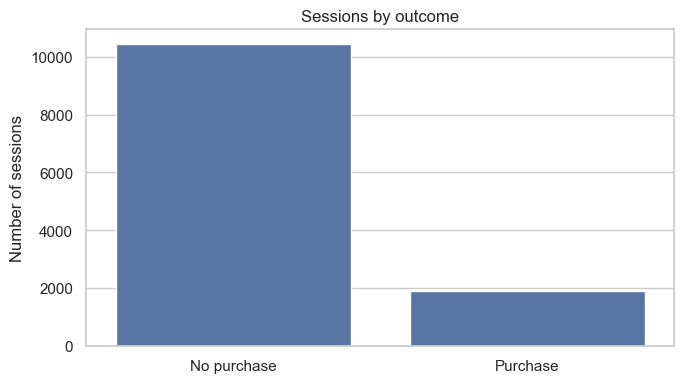

In [3]:
target_summary = y.map({0: 'No purchase', 1: 'Purchase'}).value_counts().rename_axis('class').to_frame('count')
target_summary['share'] = target_summary['count'] / len(y)
display(target_summary.style.format({'share': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x=y.map({0: 'No purchase', 1: 'Purchase'}), ax=ax)
ax.set(title='Sessions by outcome', xlabel='', ylabel='Number of sessions')
plt.tight_layout()
plt.show()

## 4. Exploratory data analysis

We study numeric features, categorical features, and their relationship with purchases.

Numeric features: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']
Categorical features: ['Month', 'VisitorType']


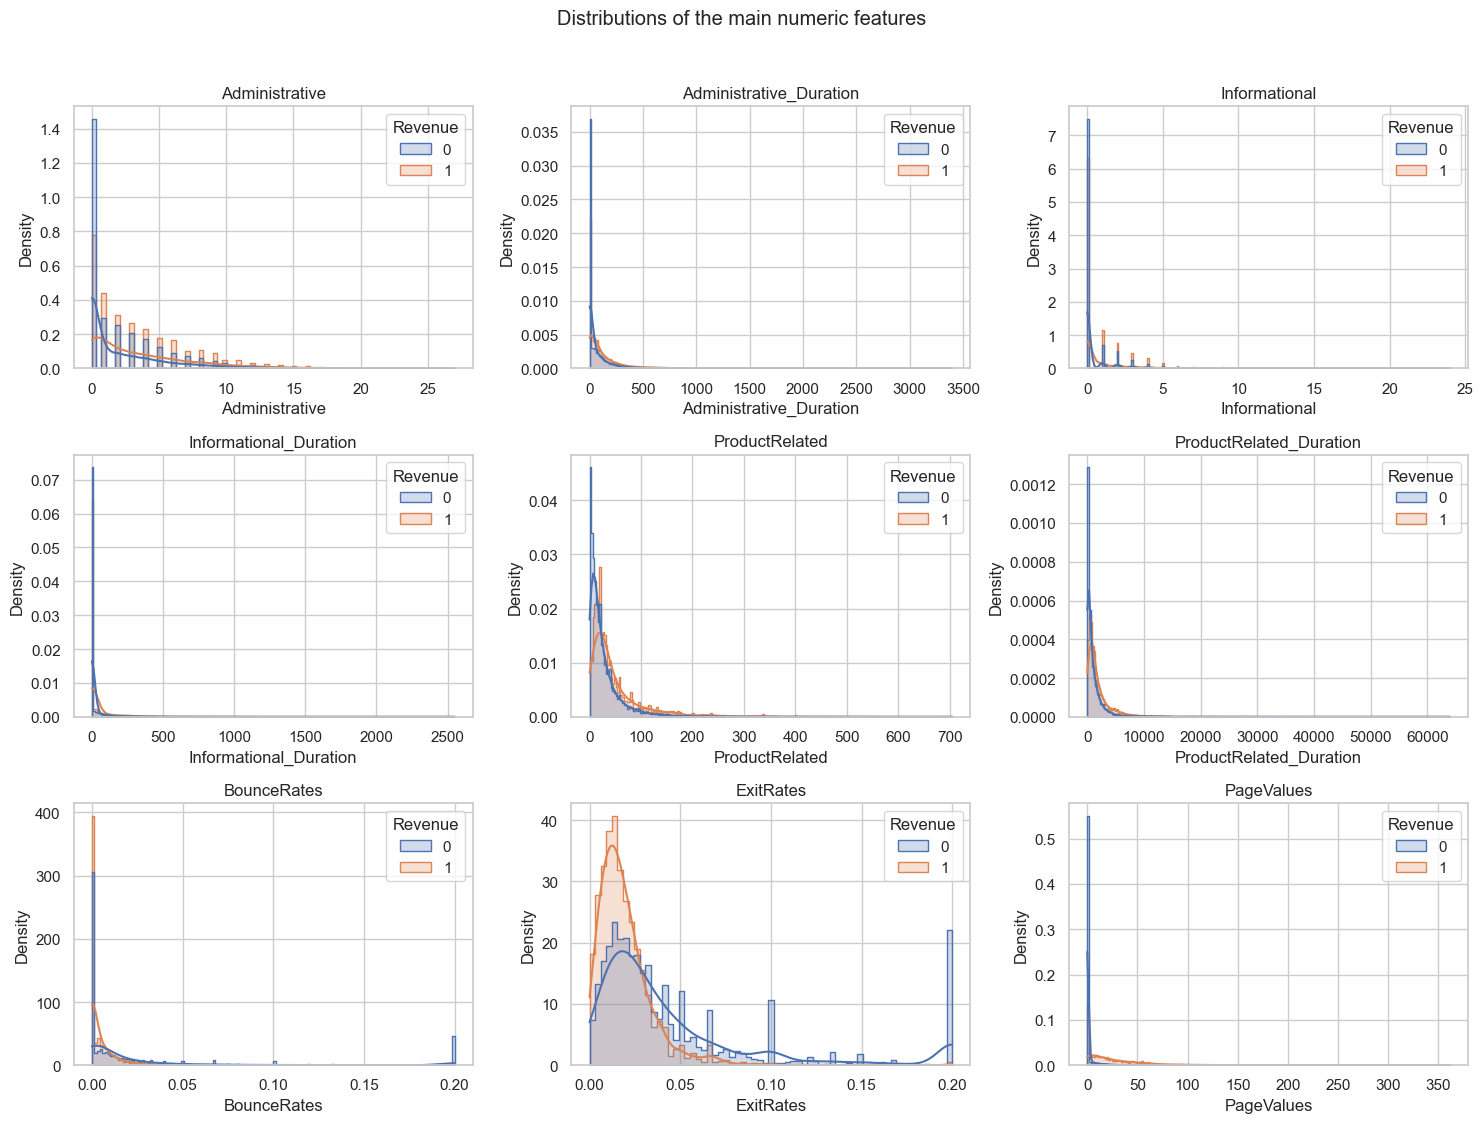

In [4]:
numeric_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Numeric features:', numeric_cols)
print('Categorical features:', categorical_cols)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, column in zip(axes.flat, numeric_cols[:9]):
    sns.histplot(data=X.assign(Revenue=y), x=column, hue='Revenue', kde=True,
                 stat='density', common_norm=False, element='step', ax=ax)
    ax.set_title(column)
for ax in axes.flat[len(numeric_cols[:9]):]:
    ax.set_visible(False)
plt.suptitle('Distributions of the main numeric features', y=1.02)
plt.tight_layout()
plt.show()

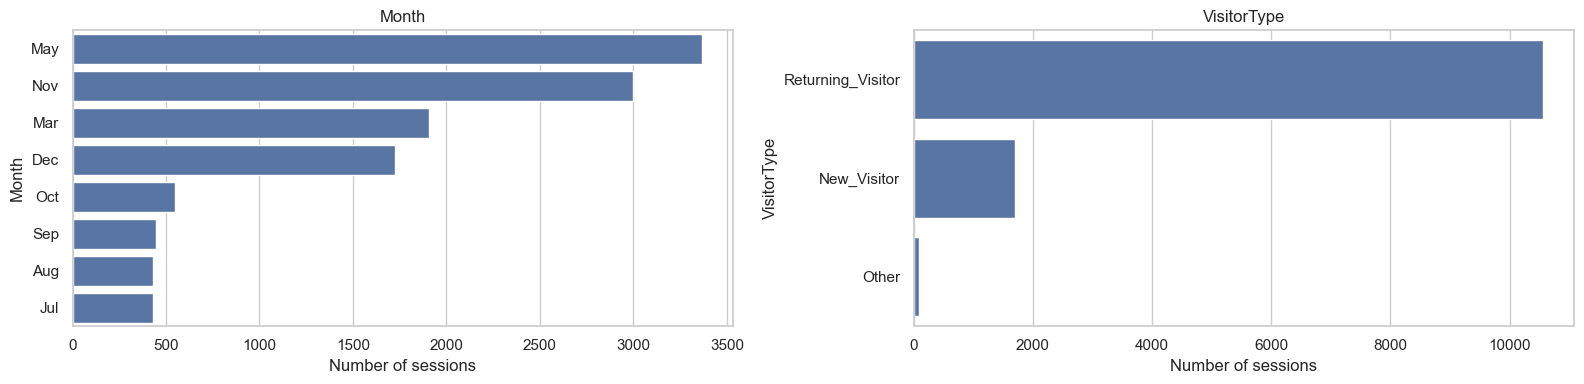

,correlation with purchase
ExitRates,-0.207071
BounceRates,-0.150673
SpecialDay,-0.082305
OperatingSystems,-0.014668
Region,-0.011595
TrafficType,-0.005113
Browser,0.023984
Informational_Duration,0.070345
Administrative_Duration,0.093587
Informational,0.095200


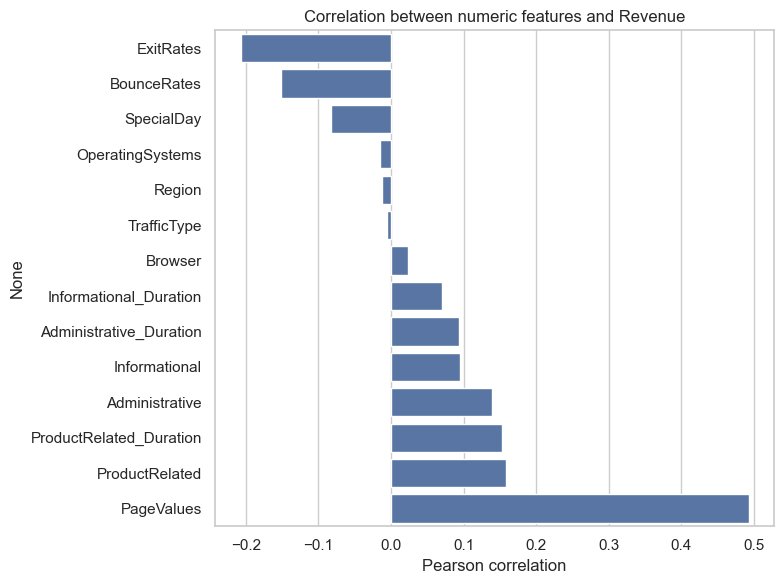

In [5]:
if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(16, 4))
    axes = np.atleast_1d(axes)
    for ax, column in zip(axes, categorical_cols):
        order = X[column].value_counts().head(8).index
        sns.countplot(data=X[X[column].isin(order)], y=column, order=order, ax=ax)
        ax.set_title(column)
        ax.set_xlabel('Number of sessions')
    plt.tight_layout()
    plt.show()

correlations = X.assign(Revenue=y).select_dtypes(include=np.number).corr()['Revenue'].drop('Revenue').sort_values()
display(correlations.to_frame('correlation with purchase'))
plt.figure(figsize=(8, 6))
sns.barplot(x=correlations.values, y=correlations.index, orient='h')
plt.title('Correlation between numeric features and Revenue')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()

## 5. Prepare the data and build models

Preprocessing is part of each pipeline. This prevents information from the test set leaking into training. We use a stratified split: 80% for training and 20% for testing.

We use 5-fold cross-validation on the training set. We also tune the Random Forest parameters and choose the classification threshold from out-of-fold predictions instead of assuming that `0.5` is always best.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(handle_unknown='ignore')),
])
preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_cols),
    ('categorical', categorical_pipeline, categorical_cols),
])

models = {
    'Logistic Regression': Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE))]),
    'Random Forest': Pipeline([('preprocessor', preprocessor), ('model', RandomForestClassifier(class_weight='balanced', n_estimators=300, min_samples_leaf=2, n_jobs=-1, random_state=RANDOM_STATE))]),
}

In [7]:
def find_f1_threshold(target, probabilities):
    precision, recall, thresholds = precision_recall_curve(target, probabilities)
    f1_scores = (2 * precision * recall / (precision + recall + 1e-12))[:-1]
    return float(thresholds[f1_scores.argmax()])


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
random_forest_search = GridSearchCV(
    models['Random Forest'],
    param_grid={
        'model__n_estimators': [200, 300],
        'model__max_depth': [None, 12],
        'model__min_samples_leaf': [1, 2],
    },
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
)
random_forest_search.fit(X_train, y_train)
models['Random Forest'] = random_forest_search.best_estimator_

results = {}
predictions = {}
probabilities = {}
validation_results = {}
thresholds = {}
for name, model in models.items():
    cv_scores = cross_validate(
        model, X_train, y_train, cv=cv,
        scoring={'roc_auc': 'roc_auc', 'pr_auc': 'average_precision'},
        n_jobs=1,
    )
    validation_results[name] = {
        'CV ROC-AUC mean': cv_scores['test_roc_auc'].mean(),
        'CV ROC-AUC std': cv_scores['test_roc_auc'].std(),
        'CV PR-AUC mean': cv_scores['test_pr_auc'].mean(),
        'CV PR-AUC std': cv_scores['test_pr_auc'].std(),
    }
    out_of_fold_probabilities = cross_val_predict(
        model, X_train, y_train, cv=cv, method='predict_proba', n_jobs=1
    )[:, 1]
    thresholds[name] = find_f1_threshold(y_train, out_of_fold_probabilities)
    model.fit(X_train, y_train)
    probabilities[name] = model.predict_proba(X_test)[:, 1]
    predictions[name] = (probabilities[name] >= thresholds[name]).astype(int)
    results[name] = {
        'ROC-AUC': roc_auc_score(y_test, probabilities[name]),
        'PR-AUC': average_precision_score(y_test, probabilities[name]),
        'F1': f1_score(y_test, predictions[name]),
        'Balanced accuracy': balanced_accuracy_score(y_test, predictions[name]),
        'Accuracy': accuracy_score(y_test, predictions[name]),
        'Threshold': thresholds[name],
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
validation_df = pd.DataFrame(validation_results).T
print('Cross-validation results:')
display(validation_df.style.format('{:.4f}'))
print('Test set results:')
display(results_df.style.format('{:.4f}'))
print(f'Best model by ROC-AUC: {results_df.index[0]}')
print('Best Random Forest parameters:', random_forest_search.best_params_)

Cross-validation results:


,CV ROC-AUC mean,CV ROC-AUC std,CV PR-AUC mean,CV PR-AUC std
Logistic Regression,0.9058,0.0054,0.6593,0.0172
Random Forest,0.9327,0.0036,0.7481,0.0168


Test set results:


,ROC-AUC,PR-AUC,F1,Balanced accuracy,Accuracy,Threshold
Random Forest,0.9253,0.7323,0.6716,0.8194,0.8917,0.4180
Logistic Regression,0.8962,0.6258,0.6313,0.7983,0.8759,0.5632


Best model by ROC-AUC: Random Forest
Best Random Forest parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}


## 6. ROC and Precision-Recall curves and confusion matrices

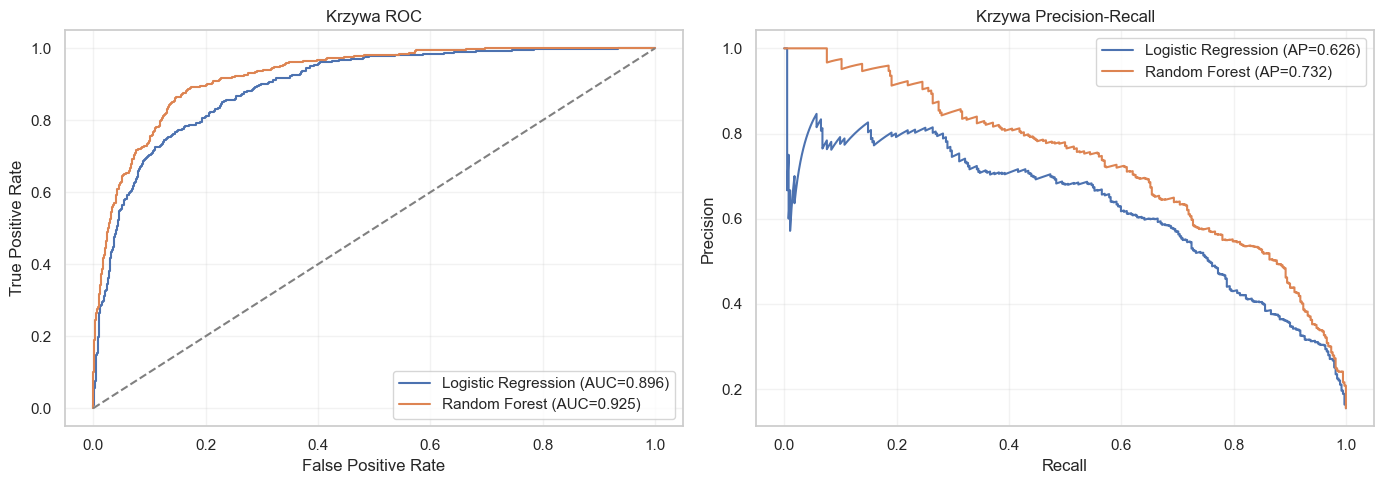

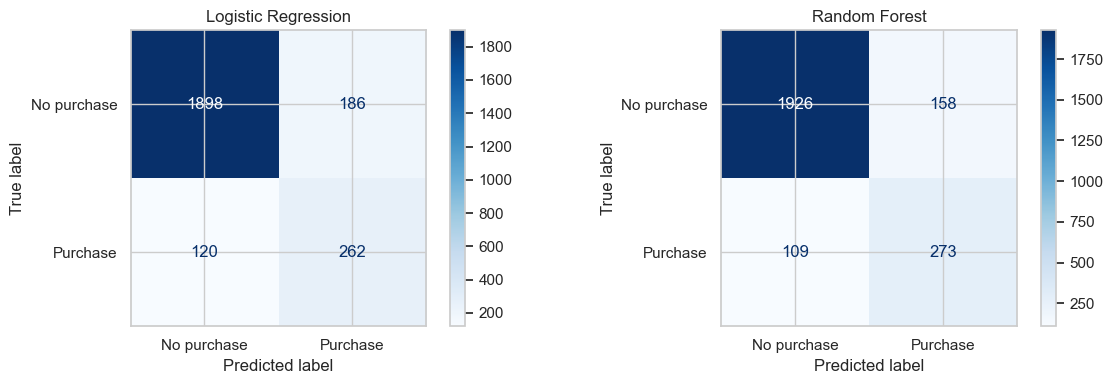

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    precision, recall, _ = precision_recall_curve(y_test, probability)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={results[name]["ROC-AUC"]:.3f})')
    axes[1].plot(recall, precision, label=f'{name} (AP={results[name]["PR-AUC"]:.3f})')
axes[0].plot([0, 1], [0, 1], '--', color='gray')
axes[0].set(title='Krzywa ROC', xlabel='False Positive Rate', ylabel='True Positive Rate')
axes[1].set(title='Krzywa Precision-Recall', xlabel='Recall', ylabel='Precision')
for ax in axes:
    ax.legend()
    ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, prediction) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, prediction, display_labels=['No purchase', 'Purchase'], cmap='Blues', values_format='d', ax=ax)
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 7. Understand the Random Forest model

After preprocessing, we get the feature names after one-hot encoding. We then show the features that have the largest effect on the model predictions.

,importance
numeric__PageValues,0.410348
numeric__ExitRates,0.092157
numeric__ProductRelated_Duration,0.088812
numeric__ProductRelated,0.063083
numeric__BounceRates,0.057811
numeric__Administrative_Duration,0.049020
numeric__Administrative,0.035520
categorical__Month_Nov,0.028697
numeric__TrafficType,0.023856
numeric__Region,0.022350


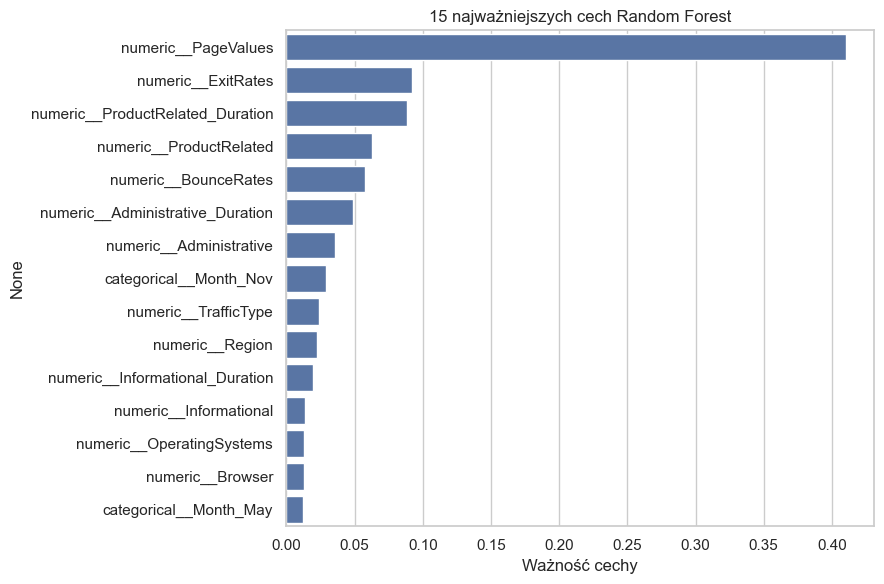

In [9]:
forest = models['Random Forest']
feature_names = forest.named_steps['preprocessor'].get_feature_names_out()
importance = pd.Series(forest.named_steps['model'].feature_importances_, index=feature_names).sort_values(ascending=False).head(15)
display(importance.to_frame('importance'))
plt.figure(figsize=(9, 6))
sns.barplot(x=importance.values, y=importance.index, orient='h')
plt.title('15 najważniejszych cech Random Forest')
plt.xlabel('Ważność cechy')
plt.tight_layout()
plt.show()

## 8. Business conclusions and limitations

- The dataset is unbalanced: purchases make up about 15.5% of all sessions.
- Random Forest has better ROC-AUC and PR-AUC than Logistic Regression, so it ranks sessions by purchase probability more effectively.
- At the 0.5 threshold, the model does not detect every purchase. The threshold should be chosen based on the cost of a missed sale and the cost of an unnecessary campaign.
- The model can support personalized messages and session prioritization, but it should not be the only source for business decisions.
- Limitations: the data describes past sessions, behavior can change over time, and the dataset does not contain the full user context. Before deployment, use time-based testing, probability calibration, and drift monitoring.